# Massachusetts Roads Dataset

here I will we moddifying the model and seeing the difference in performance.

In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/massachusetts-roads-dataset",force_download=True)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'massachusetts-roads-dataset' dataset.
Path to dataset files: /kaggle/input/massachusetts-roads-dataset


In [3]:
dirc = path
doc_file = pd.read_csv(dirc+"/metadata.csv")
doc_file

,image_id,split,image_souce_url,label_source_url,tiff_image_path,tif_label_path,png_image_path,png_label_path
0,10078660_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078660_15.tiff,tiff/train_labels/10078660_15.tif,png/train/10078660_15.png,png/train_labels/10078660_15.png
1,10078675_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078675_15.tiff,tiff/train_labels/10078675_15.tif,png/train/10078675_15.png,png/train_labels/10078675_15.png
2,10078690_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078690_15.tiff,tiff/train_labels/10078690_15.tif,png/train/10078690_15.png,png/train_labels/10078690_15.png
3,10078705_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078705_15.tiff,tiff/train_labels/10078705_15.tif,png/train/10078705_15.png,png/train_labels/10078705_15.png
4,10078720_15,train,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/train/10078720_15.tiff,tiff/train_labels/10078720_15.tif,png/train/10078720_15.png,png/train_labels/10078720_15.png
...,...,...,...,...,...,...,...,...
1166,25079170_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/25079170_15.tiff,tiff/test_labels/25079170_15.tif,png/test/25079170_15.png,png/test_labels/25079170_15.png
1167,26278720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26278720_15.tiff,tiff/test_labels/26278720_15.tif,png/test/26278720_15.png,png/test_labels/26278720_15.png
1168,26428735_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26428735_15.tiff,tiff/test_labels/26428735_15.tif,png/test/26428735_15.png,png/test_labels/26428735_15.png
1169,26578720_15,test,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,http://www.cs.toronto.edu/~vmnih/data/mass_roa...,tiff/test/26578720_15.tiff,tiff/test_labels/26578720_15.tif,png/test/26578720_15.png,png/test_labels/26578720_15.png


In [4]:
import os

train_files = doc_file[doc_file["split"] == "train"]["tiff_image_path"]
train_label_files = doc_file[doc_file["split"] == "train"]["tif_label_path"]

train_files = [os.path.join(dirc,f) for f in train_files]
train_label_files = [os.path.join(dirc,f) for f in train_label_files]
train_files = [Image.open(f).resize((256,256)) for f in train_files]
train_label_files = [Image.open(f).resize((256,256)) for f in train_label_files]

In [5]:
from torch.utils.data import DataLoader,Dataset

class RoadDataset(Dataset):
    def __init__(self, inputs, labels, transform, label_transform):
        self.x = [transform(i) for i in inputs]
        self.y = [label_transform(inputs[i],labels[i]) for i in range(len(labels))]

    def __len__(self):
        return len(self.y)

    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]



In [6]:
def input_transform(x:Image.Image,mean,std):
    x = np.asarray(x,dtype=np.float32)/255.0
    x = torch.tensor(x).transpose(-1,-2).transpose(-2,-3)
    return x

def label_transform(x:torch.Tensor, y:Image.Image):
    y = np.asarray(y,dtype=np.float32)/255.0
    y = torch.tensor(y)

    x_ = torch.Tensor(np.asarray(x)).mean(dim=-1)
    x_ = torch.where(x_ == 255, 0, 1)
    #y = torch.where(y > 0.5, 1, 0)
    return y*x_


In [7]:
x = np.asarray([np.asarray(i,dtype=np.float32)/255.0 for i  in train_files])
mean = np.mean(x)
std = np.std(x)
in_transform = lambda x : input_transform(x,mean,std)
train_dataset = RoadDataset(train_files,train_label_files,in_transform,label_transform)
train_size = len(train_dataset)

/tmp/ipykernel_1082/3209347651.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  x_ = torch.Tensor(np.asarray(x)).mean(dim=-1)


In [8]:
valid_files = doc_file[doc_file["split"] == "val"]["tiff_image_path"]
valid_label_files = doc_file[doc_file["split"] == "val"]["tif_label_path"]

valid_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_files]
valid_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in valid_label_files]

valid_dataset = RoadDataset(valid_files,valid_label_files,in_transform,label_transform)
valid_size = len(valid_dataset)

In [9]:
test_files = doc_file[doc_file["split"] == "test"]["tiff_image_path"]
test_label_files = doc_file[doc_file["split"] == "test"]["tif_label_path"]

test_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_files]
test_label_files = [Image.open(os.path.join(dirc,f)).resize((256,256)) for f in test_label_files]

test_dataset = RoadDataset(test_files,test_label_files,in_transform,label_transform)
test_size = len(test_dataset)

# Improving the U-net model

To improve the model:

i) and more convolution to make better features

ii) rather than simple skip connections, a convolution layer is also added to make it more useful.

In [10]:
class MultiConv(nn.Module):
  def __init__(self,x,y,z):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(x,y,3,padding = "same"),
        nn.BatchNorm2d(y),
        nn.Conv2d(y,y,3,padding = "same"),
        nn.BatchNorm2d(y),
        nn.Conv2d(y,z,3,padding = "same"),
    )

  def forward(self, x):
    return self.model(x)



class RoadPredictor(nn.Module):
    def __init__(self,device):
        super().__init__()
        self.convs = nn.ModuleList([MultiConv(3,4,4).to(device),
                                    MultiConv(4,4,4).to(device),
                                    MultiConv(4,4,4).to(device),
                                    MultiConv(4,8,4).to(device),
                                    MultiConv(8,4,4).to(device),
                                    MultiConv(4,8,4).to(device),
                                    MultiConv(8,4,1).to(device),
                                    ])
        self.maxpool = nn.ModuleList([nn.MaxPool2d(2).to(device) for i in range(2)])
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(4,4,2,stride=2).to(device) for i in range(2)])

    def forward(self,x):
        x1 = self.convs[0](x)
        x2 = self.maxpool[0](x1)
        x3 = self.convs[1](x2)
        x4 = self.maxpool[1](x3)
        x5 = self.convs[2](x4)
        x6 = self.upconvs[0](x5)
        x6 = torch.concat([x6,self.convs[3](x3)], dim=1)
        x7 = self.convs[4](x6)
        x8 = self.upconvs[1](x7)
        x8 = torch.concat([x8,self.convs[5](x1)], dim=1)
        x8 = self.convs[6](x8)
        return x8.reshape(-1,256*256)

In [11]:
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        intersection = torch.dot(pred,target)
        dice = (2.*intersection)/(pred.sum() + target.sum())
        return 1 - dice

class BCEAndDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = nn.BCEWithLogitsLoss()
        self.loss2 = DiceLoss()

    def forward(self, pred, target):
        return .005*self.loss1(pred,target) + self.loss2(pred,target)

class DoubleDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss1 = DiceLoss()
        self.loss2 = DiceLoss()
    def forward(self, pred, target):
        return self.loss1(pred,target) + 1e-3*self.loss2(1 - pred,1 - target)

class FocalLoss(nn.Module):
    def __init__(self, weight=1., gamma = 2.):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.reshape(-1)
        target = target.reshape(-1)
        l = (1 - self.weight)*target*((1 - pred)**self.gamma)*torch.log(pred) + self.weight*(1 - target)*(pred**self.gamma)*torch.log(1 - pred)
        return -l.sum()

In [12]:

def train_model(model,loss_fn,opt,max_epochs,train_data,valid_data,device):
    model = model.to(device)
    loss_fn = loss_fn.to(device)
    accuracy = []
    losses = []
    model.train()
    for i in range(max_epochs):
        s = 0
        for (x,y) in train_data:
            y = y.to(device).reshape(-1,256*256)
            x = x.to(device)
            pred = model(x)
            loss = loss_fn(pred,y)
            losses.append(loss.cpu().item())
            loss.backward()
            s+=loss.item()
            opt.step()
            opt.zero_grad()
        with torch.no_grad():
            total = 0
            for (x,y) in valid_data:
                y = y.to(device).reshape(-1,256*256)
                x = x.to(device)
                pred = model(x)
                pred = torch.sigmoid(pred)
                pred = torch.where(pred >= 0.5, 1, 0)
                total += (y == pred).reshape(-1).sum().cpu().item()
            accuracy.append(total/valid_size/256/256)
            if (i%10 == 0):
                print(f"Epoch {i+1}: valid acc :{accuracy[-1]} training_loss:{losses[-1]}")

    return model, accuracy , losses

In [13]:
def diceloss(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = (2.*intersection)/(pred.sum() + target.sum())
    return score

def iou(target, pred):
    pred = torch.sigmoid(pred)
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    intersection = torch.dot(pred,target)
    score = intersection/(pred.sum() + target.sum()-intersection)
    return score

def eval_model(model,test_data):
  model.eval()
  tp= tn = fp = fn = 0
  dice_loss = 0
  iou_loss = 0
  for (x,y) in test_data:
    x = x.to(device)
    y = y.to(device).reshape(-1,256*256)
    pred = model(x)
    y_ = torch.where(y >0.5, 1, 0)
    pred_ = torch.where(pred > 0.5, 1, 0)
    matches = (y_ == pred_)
    tp += (matches*(y_==1)).sum()
    tn += (matches*(y_==0)).sum()
    fp += ((~matches)*(y_==1)).sum()
    fn += ((~matches)*(y_==0)).sum()
    dice_loss += diceloss(y,pred)
    iou_loss += iou(y,pred)
  print(f"""
  Accuracy: {(tp+tn)/(tp+tn+fp+fn)}
  Recall: {(tp)/(tp+fn)}
  Presicion: {(tp)/(tp+fp)}
  IOU: {iou_loss}
  diceloss: {dice_loss}
  """)


In [14]:
train_data = DataLoader(train_dataset,batch_size=256)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

In [15]:
import gc

gc.collect()

torch.cuda.empty_cache()

Epoch 1: valid acc :0.32392665318080355 training_loss:0.9576705098152161
Epoch 11: valid acc :0.4686944144112723 training_loss:0.9321430921554565
Epoch 21: valid acc :0.5579986572265625 training_loss:0.9176674485206604
Epoch 31: valid acc :0.6073619297572544 training_loss:0.9016640782356262
Epoch 41: valid acc :0.6619415283203125 training_loss:0.8844688534736633
Epoch 51: valid acc :0.7401253836495536 training_loss:0.8463649153709412
Epoch 61: valid acc :0.7830527169363839 training_loss:0.7907124757766724
Epoch 71: valid acc :0.8070602416992188 training_loss:0.7383150458335876
Epoch 81: valid acc :0.80670166015625 training_loss:0.7021021842956543
Epoch 91: valid acc :0.8069370814732143 training_loss:0.6792729496955872
Epoch 101: valid acc :0.8072989327566964 training_loss:0.6586858034133911
Epoch 111: valid acc :0.8047768729073661 training_loss:0.6463168263435364
Epoch 121: valid acc :0.8051180158342633 training_loss:0.6363117098808289
Epoch 131: valid acc :0.8053316388811383 training_

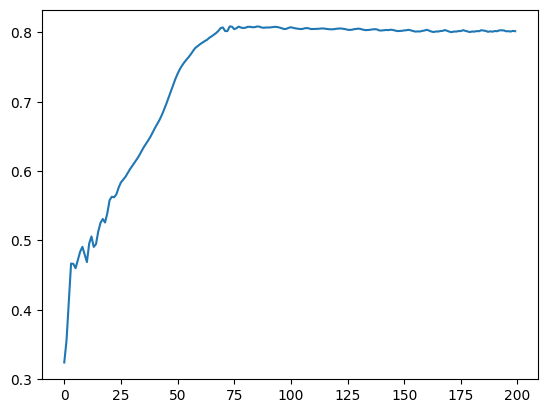

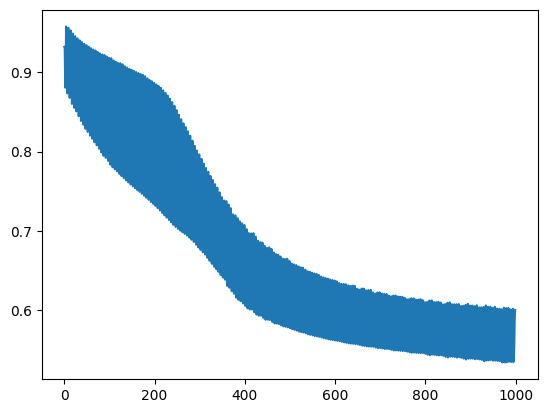

In [16]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = RoadPredictor(device)
loss_fn = DiceLoss()
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_diceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.9446909427642822
  Recall: 0.4517928659915924
  Presicion: 0.5604997277259827
  IOU: 0.29880213737487793
  diceloss: 0.4601195454597473
  


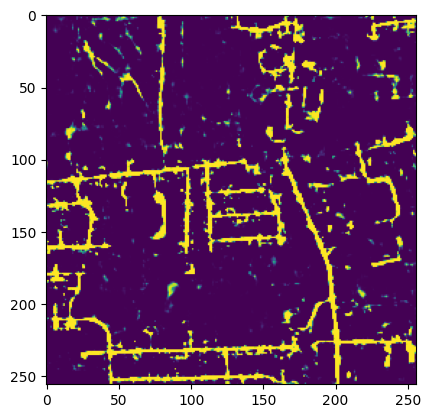

In [17]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_diceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = (pred[0])
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_diceloss,test_data)

Epoch 1: valid acc :0.32179151262555805 training_loss:9827.9921875
Epoch 11: valid acc :0.3378840855189732 training_loss:6511.7880859375
Epoch 21: valid acc :0.31612941196986605 training_loss:6342.63623046875
Epoch 31: valid acc :0.29626246861049105 training_loss:6392.3388671875
Epoch 41: valid acc :0.2798549107142857 training_loss:6455.75830078125
Epoch 51: valid acc :0.26672581263950895 training_loss:6500.48828125
Epoch 61: valid acc :0.2551204136439732 training_loss:6518.05615234375
Epoch 71: valid acc :0.23593902587890625 training_loss:6507.451171875
Epoch 81: valid acc :0.22765677315848215 training_loss:6479.3671875
Epoch 91: valid acc :0.2400545392717634 training_loss:6425.0498046875
Epoch 101: valid acc :0.2496610369001116 training_loss:6362.9072265625
Epoch 111: valid acc :0.2580806187220982 training_loss:6306.416015625
Epoch 121: valid acc :0.2674811226981027 training_loss:6253.880859375
Epoch 131: valid acc :0.2783628191266741 training_loss:6205.12744140625
Epoch 141: valid a

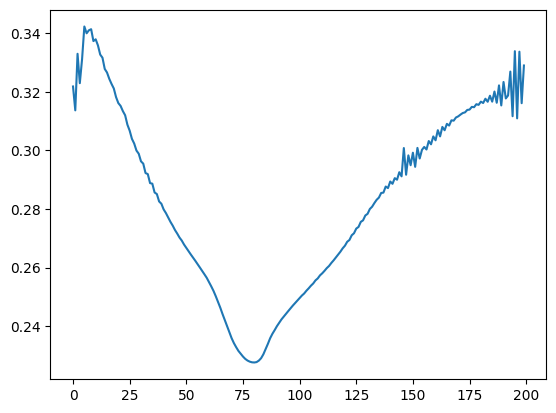

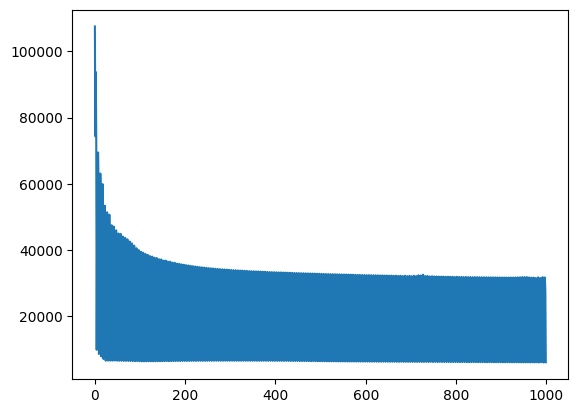

In [18]:
model = RoadPredictor(device)
loss_fn = FocalLoss(5e-3,3)
opt = torch.optim.AdamW(model.parameters(),lr = 1e-3)
model_focalloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.7066519856452942
  Recall: 0.1350572556257248
  Presicion: 0.9137591123580933
  IOU: 0.05890076979994774
  diceloss: 0.11124889552593231
  


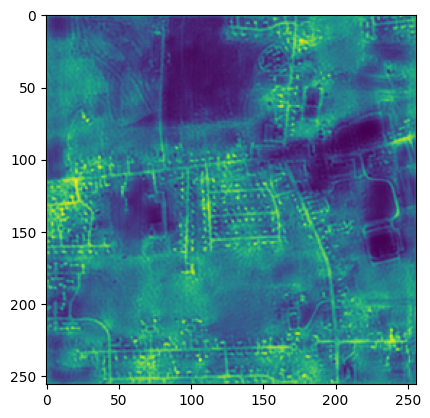

In [19]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_focalloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_focalloss,test_data)

Epoch 1: valid acc :0.2642887660435268 training_loss:0.7707085609436035
Epoch 11: valid acc :0.6089542933872768 training_loss:0.6623071432113647
Epoch 21: valid acc :0.8240378243582589 training_loss:0.4422479569911957
Epoch 31: valid acc :0.8474328177315849 training_loss:0.24437063932418823
Epoch 41: valid acc :0.8474012102399554 training_loss:0.15199148654937744
Epoch 51: valid acc :0.8461478097098214 training_loss:0.11507463455200195
Epoch 61: valid acc :0.8447178431919643 training_loss:0.0980808287858963
Epoch 71: valid acc :0.8424442836216518 training_loss:0.08869215846061707
Epoch 81: valid acc :0.840346200125558 training_loss:0.0828404575586319
Epoch 91: valid acc :0.8381805419921875 training_loss:0.07909814268350601
Epoch 101: valid acc :0.8374590192522321 training_loss:0.07653197646141052
Epoch 111: valid acc :0.8373042515345982 training_loss:0.07470859587192535
Epoch 121: valid acc :0.8374928065708706 training_loss:0.07336626201868057
Epoch 131: valid acc :0.837677001953125 tr

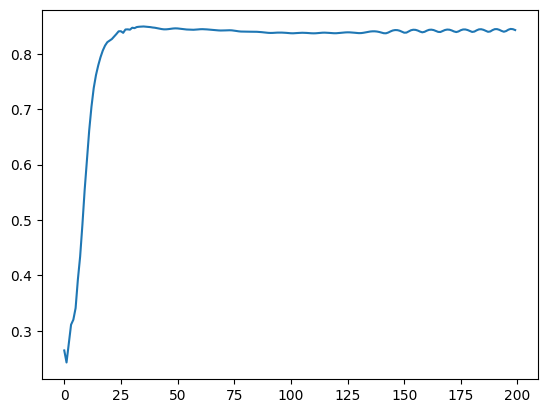

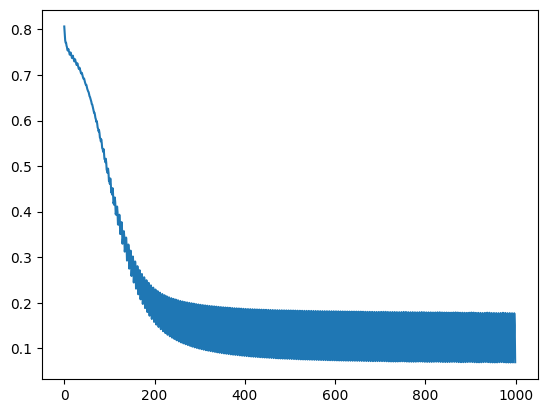

In [20]:
model = RoadPredictor(device)
loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(),lr = 1e-3)
model_bce,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)
plt.show()


  Accuracy: 0.9529767632484436
  Recall: 0.6953473091125488
  Presicion: 0.08563575893640518
  IOU: 0.13610906898975372
  diceloss: 0.23960565030574799
  


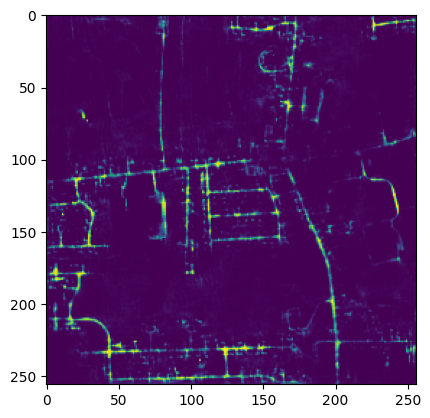

In [21]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bce(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bce,test_data)

Epoch 1: valid acc :0.47238268171037945 training_loss:0.9526272416114807
Epoch 11: valid acc :0.5693424769810268 training_loss:0.9186903238296509
Epoch 21: valid acc :0.6546031406947544 training_loss:0.8902536034584045
Epoch 31: valid acc :0.7654397147042411 training_loss:0.802964985370636
Epoch 41: valid acc :0.77386474609375 training_loss:0.7476173639297485
Epoch 51: valid acc :0.7947354997907367 training_loss:0.6961348652839661
Epoch 61: valid acc :0.8083343505859375 training_loss:0.6645777225494385
Epoch 71: valid acc :0.8069163731166294 training_loss:0.644405722618103
Epoch 81: valid acc :0.8108019147600446 training_loss:0.6306623220443726
Epoch 91: valid acc :0.8119027273995536 training_loss:0.6221572756767273
Epoch 101: valid acc :0.8122166224888393 training_loss:0.6155744791030884
Epoch 111: valid acc :0.8099757603236607 training_loss:0.610602855682373
Epoch 121: valid acc :0.8107332502092633 training_loss:0.6052260994911194
Epoch 131: valid acc :0.8107125418526786 training_los

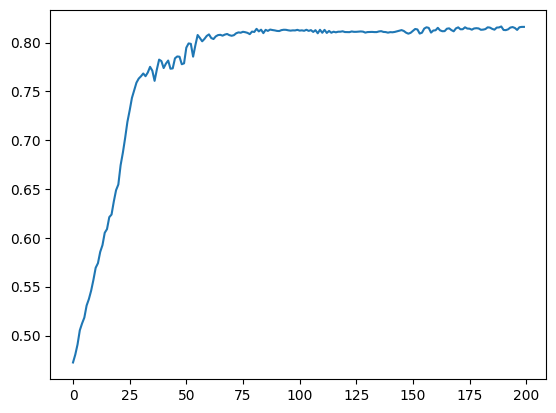

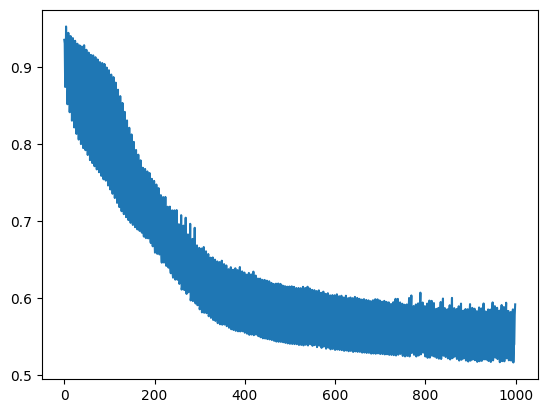

In [22]:
model = RoadPredictor(device)
loss_fn = BCEAndDiceLoss()
opt = torch.optim.Adam(model.parameters(),lr = 2e-3)
model_bceanddiceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.9500315189361572
  Recall: 0.4947252869606018
  Presicion: 0.5395021438598633
  IOU: 0.3122359812259674
  diceloss: 0.4758839011192322
  


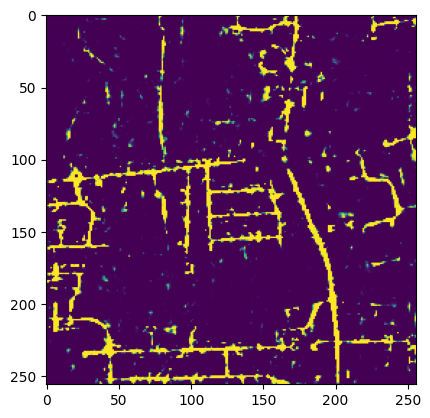

In [23]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bceanddiceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bceanddiceloss, test_data)

Epoch 1: valid acc :0.40669032505580355 training_loss:0.9562878012657166
Epoch 11: valid acc :0.5869227818080357 training_loss:0.913017749786377
Epoch 21: valid acc :0.6548025948660714 training_loss:0.8878095746040344
Epoch 31: valid acc :0.7801023210797992 training_loss:0.815813422203064
Epoch 41: valid acc :0.8221588134765625 training_loss:0.744091272354126
Epoch 51: valid acc :0.8264410836356026 training_loss:0.6988691687583923
Epoch 61: valid acc :0.828873770577567 training_loss:0.6643804311752319
Epoch 71: valid acc :0.8293130057198661 training_loss:0.6597256064414978
Epoch 81: valid acc :0.8247059413364956 training_loss:0.648645281791687
Epoch 91: valid acc :0.8233304704938617 training_loss:0.6401664018630981
Epoch 101: valid acc :0.8237555367606026 training_loss:0.6395047903060913
Epoch 111: valid acc :0.8222601754324776 training_loss:0.6245188117027283
Epoch 121: valid acc :0.8201675415039062 training_loss:0.6259891986846924
Epoch 131: valid acc :0.8203887939453125 training_los

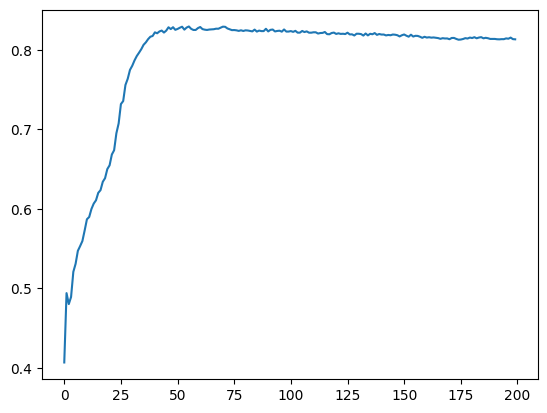

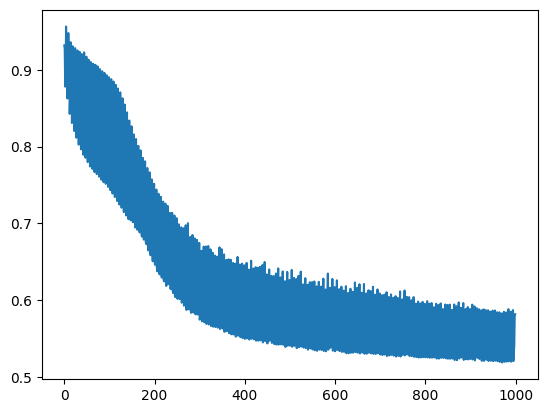

In [24]:
model = RoadPredictor(device)
loss_fn = DoubleDiceLoss()
opt = torch.optim.Adam(model.parameters(),lr = 2e-3)
model_bceanddiceloss,accuracy,losses = train_model(model,loss_fn,opt,200,train_data,valid_data,device)

plt.plot(accuracy)
plt.show()
plt.plot(losses)


  Accuracy: 0.946321427822113
  Recall: 0.46392542123794556
  Presicion: 0.5568877458572388
  IOU: 0.30534330010414124
  diceloss: 0.4678359925746918
  


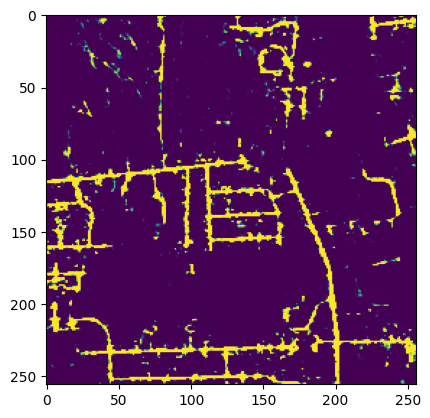

In [26]:
with torch.no_grad():
    total = 0
    for (x,y) in valid_data:
        y = y.to(device).reshape((-1,256*256))
        x = x.to(device)
        pred = model_bceanddiceloss(x)
        pred = torch.sigmoid(pred)
        break
pred2 = pred[0]
plt.imshow(pred2.reshape(256,256).cpu())
eval_model(model_bceanddiceloss, test_data)

In [27]:
torch.save(model_focal.state_dict(), f"./model_focal.trhmodel")
torch.save(model_doublediceloss.state_dict(), f"./model_doublediceloss.trhmodel")
torch.save(model_bceanddiceloss.state_dict(), f"./model_bceanddiceloss.trhmodel")
torch.save(model_bce.state_dict(), f"./model_bce.trhmodel")
torch.save(model_diceloss.state_dict(), f"./model_diceloss.trhmodel")

NameError: name 'model_focal' is not defined